In [1]:
from pathlib import Path

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 11,
})

BLUE = "#2563EB"
RED = "#DC2626"
COLORS = {"real": BLUE, "reconstructed": RED}
LABELS = [
    r"$f_0-f_{0,\mathrm{true}}$ [$\mu$Hz]",
    r"$\dot f$ [$10^{-15}$ Hz s$^{-1}$]",
    r"$\sin\beta$",
    r"$\lambda$ [rad]",
    r"$A$ [$10^{-22}$]",
    r"$\cos\iota$",
]

RELATIVE_DISPERSION_U = {
    "posteriors_snr_low_quality_1_reconstructed.npz": 89.33,
    "posteriors_snr_low_quality_2_reconstructed.npz": 45.49,
    "posteriors_snr_low_quality_3_reconstructed.npz": 16.78,
    "posteriors_snr_medium_quality_1_reconstructed.npz": 54.29,
    "posteriors_snr_medium_quality_2_reconstructed.npz": 26.55,
    "posteriors_snr_medium_quality_3_reconstructed.npz": 11.75,
    "posteriors_snr_high_quality_1_reconstructed.npz": 41.34,
    "posteriors_snr_high_quality_2_reconstructed.npz": 48.15,
    "posteriors_snr_high_quality_3_reconstructed.npz": 7.07,
}

In [2]:
plt.rcParams.update({
    "font.family": "Optima",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "text.usetex": True,
})

In [3]:
# POSTERIOR_PATH = Path("posterior_different_noise/posterior/posteriors_snr_medium_quality_1_real.npz")
POSTERIOR_PATH = Path("posterior_different_noise/posterior/posteriors_snr_medium_quality_3_real.npz")
# POSTERIOR_PATH = Path("posterior_different_noise/posterior/posteriors_snr_high_quality_3_real.npz")

BURN_IN = 100
H5_PATH = Path("reconstructed_waveform.h5")
MAX_CORNER_SAMPLES = 50_000

In [4]:
def companion_paths(selected_path):
    selected_path = Path(selected_path)
    if selected_path.suffix == ".npy":
        raise ValueError(
            "Legacy .npy files contain neither chains nor "
            "log-likelihoods. Rerun run_mcmc.py to create the .npz files."
        )
    if selected_path.name.endswith("_real.npz"):
        companion = selected_path.with_name(
            selected_path.name.replace("_real.npz", "_reconstructed.npz")
        )
    elif selected_path.name.endswith("_reconstructed.npz"):
        companion = selected_path.with_name(
            selected_path.name.replace("_reconstructed.npz", "_real.npz")
        )
    else:
        raise ValueError("The filename must end with _real.npz or _reconstructed.npz.")
    for path in (selected_path, companion):
        if not path.exists():
            raise FileNotFoundError(path)
    return selected_path, companion


def load_pair(selected_path):
    posteriors = {}
    for path in companion_paths(selected_path):
        with np.load(path) as archive:
            item = {key: archive[key] for key in archive.files}
        kind = str(item["source_kind"].item())
        posteriors[kind] = item
    if set(posteriors) != {"real", "reconstructed"}:
        raise ValueError("The real/reconstructed pair is incomplete.")
    real = posteriors["real"]
    reconstructed = posteriors["reconstructed"]
    for key in ("element_index", "source_number"):
        if real[key].item() != reconstructed[key].item():
            raise ValueError(f"Incompatible metadata: {key}")
    return posteriors


def load_source_info(h5_path, element_index, source_number):
    with h5py.File(h5_path, "r") as h5_file:
        index_key = (
            "element_index" if "element_index" in h5_file else "mixture_index"
        )
        matches = np.flatnonzero(
            (h5_file[index_key][:] == element_index)
            & (h5_file["source_number"][:] == source_number)
        )
        if len(matches) != 1:
            raise ValueError(f"HDF5 source not found or ambiguous: {matches}")
        index = int(matches[0])
        return {
            "source_real": h5_file["source_real"][index],
            "source_reconstructed": h5_file["source_reconstructed"][index],
            "snr": float(h5_file["snr"][index]),
            "reconstruction_quality": int(
                h5_file["reconstruction_quality"][index]
            ),
        }


def complex_channels(waveform):
    return waveform[0] + 1j * waveform[1], waveform[2] + 1j * waveform[3]


def transform_parameters(values, reference_f0):
    transformed = np.array(values, dtype=float, copy=True)
    transformed[..., 0] = (transformed[..., 0] - reference_f0) * 1e6
    transformed[..., 1] *= 1e15
    transformed[..., 4] *= 1e22
    return transformed


def clean_negative_log_likelihood(values):
    result = -np.asarray(values, dtype=float)
    result[np.abs(result) >= 1e90] = np.nan
    return result


def median_band(values, axis=1):
    return (
        np.nanmedian(values, axis=axis),
        np.nanpercentile(values, 10, axis=axis),
        np.nanpercentile(values, 90, axis=axis),
    )

In [5]:
posteriors = load_pair(POSTERIOR_PATH)
metadata = posteriors["real"]
element_index = int(metadata["element_index"].item())
source_number = int(metadata["source_number"].item())
truth = metadata["truth"]
source_info = load_source_info(H5_PATH, element_index, source_number)
reconstructed_path = next(
    path for path in companion_paths(POSTERIOR_PATH)
    if path.name.endswith("_reconstructed.npz")
)
try:
    relative_dispersion_u = RELATIVE_DISPERSION_U[reconstructed_path.name]
except KeyError as error:
    raise KeyError(
        f"No relative-dispersion U value is configured for "
        f"{reconstructed_path.name!r}."
    ) from error

n_iterations = posteriors["real"]["chain"].shape[0]
if not 0 <= BURN_IN < n_iterations:
    raise ValueError(f"BURN_IN must be between 0 and {n_iterations - 1}.")

print(f"Element {element_index} · source {source_number}")
print(f"Iterations: {n_iterations} · burn-in: {BURN_IN}")
print(f"SNR: {source_info['snr']:.2f}")
print(f"Reconstruction quality: {source_info['reconstruction_quality']}")
print(f"Relative dispersion U: {relative_dispersion_u:.2f}")

Element 927 · source 2
Iterations: 3000 · burn-in: 100
SNR: 35.51
Reconstruction quality: 3
Relative dispersion U: 11.75


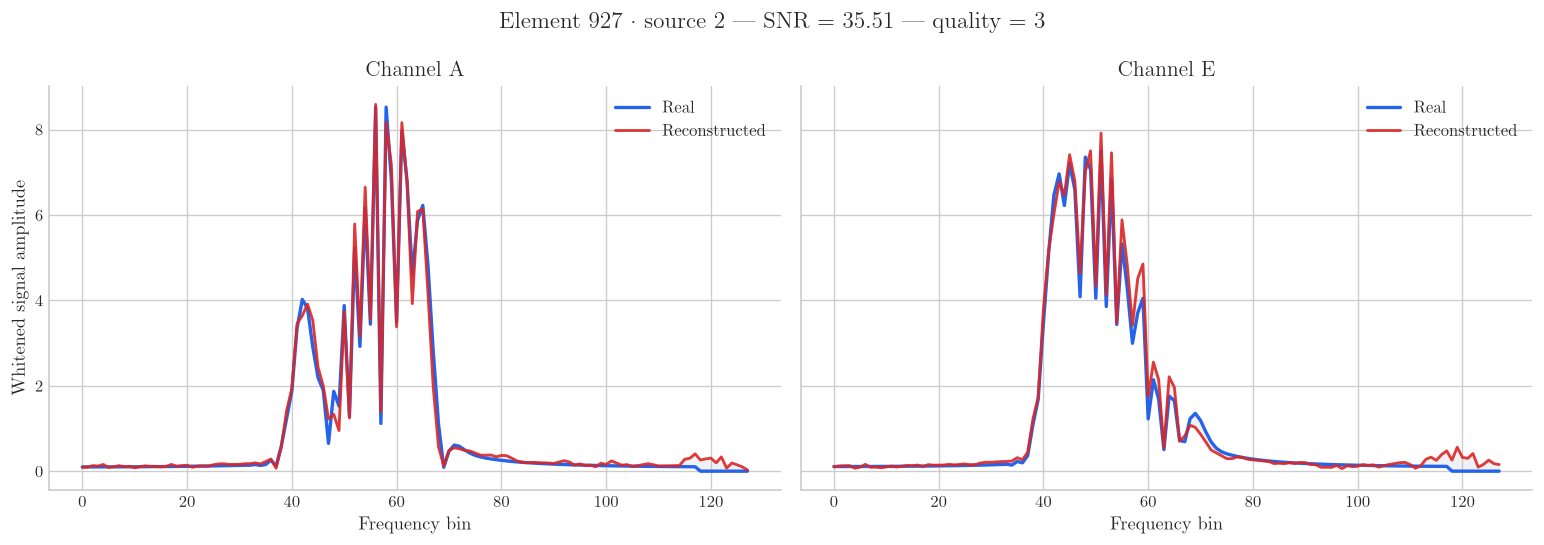

In [6]:
real_a, real_e = complex_channels(source_info["source_real"])
reconstructed_a, reconstructed_e = complex_channels(
    source_info["source_reconstructed"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, channel, real_wave, reconstructed_wave in zip(
    axes, ("A", "E"), (real_a, real_e), (reconstructed_a, reconstructed_e)
):
    bins = np.arange(len(real_wave))
    ax.plot(bins, np.abs(real_wave), color=BLUE, lw=2.0, label="Real")
    ax.plot(
        bins, np.abs(reconstructed_wave), color=RED, lw=1.7, alpha=0.9,
        label="Reconstructed"
    )
    ax.fill_between(
        bins, np.abs(real_wave), np.abs(reconstructed_wave),
        color="#94A3B8", alpha=0.15
    )
    ax.set(title=f"Channel {channel}", xlabel="Frequency bin")
    ax.legend(frameon=False)
axes[0].set_ylabel("Whitened signal amplitude")
fig.suptitle(
    f"Element {element_index} · source {source_number}  |  "
    f"SNR = {source_info['snr']:.2f}  |  "
    f"quality = {source_info['reconstruction_quality']}",
    fontsize=14, fontweight="bold",
)
fig.tight_layout()
plt.show()

## 2. Evolution of the negative log-likelihood

The line shows the median across walkers, and the shaded area shows their 10th–90th percentile interval.

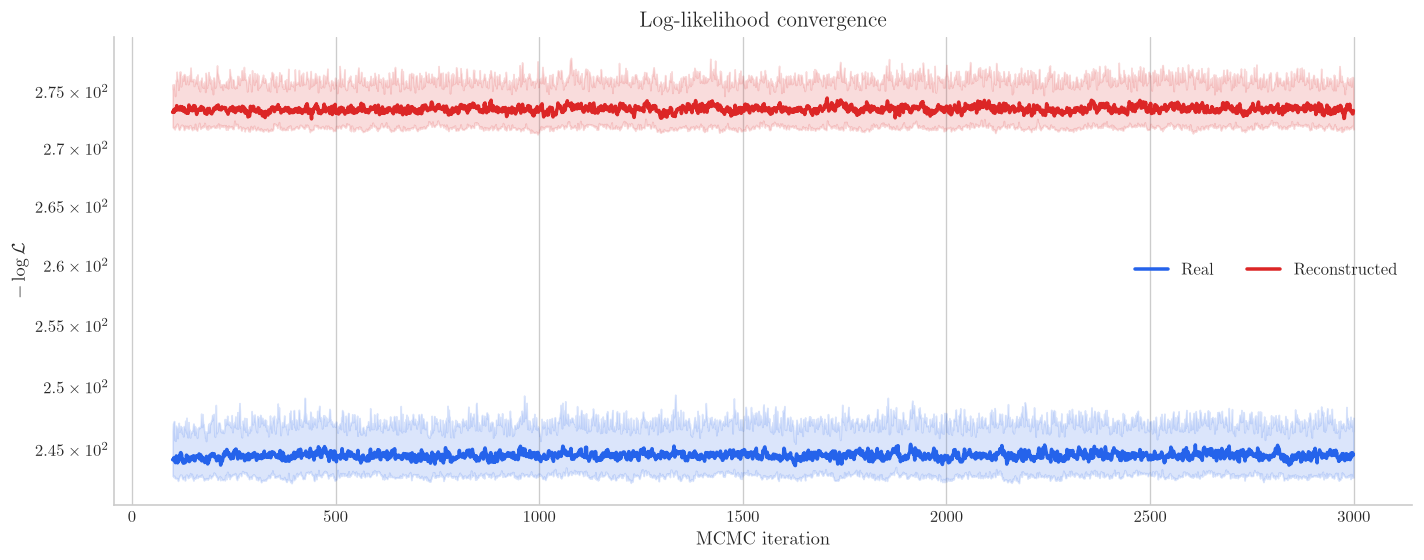

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.8))
steps = np.arange(BURN_IN, n_iterations)
for kind, label in (("real", "Real"), ("reconstructed", "Reconstructed")):
    values = clean_negative_log_likelihood(
        posteriors[kind]["log_likelihood"][BURN_IN:]
    )
    median, low, high = median_band(values)
    ax.plot(steps, median, color=COLORS[kind], lw=2.1, label=label)
    ax.fill_between(steps, low, high, color=COLORS[kind], alpha=0.16)
ax.set(
    xlabel="MCMC iteration", ylabel=r"$-\log \mathcal{L}$",
    title="Log-likelihood convergence"
)
ax.set_yscale("log")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

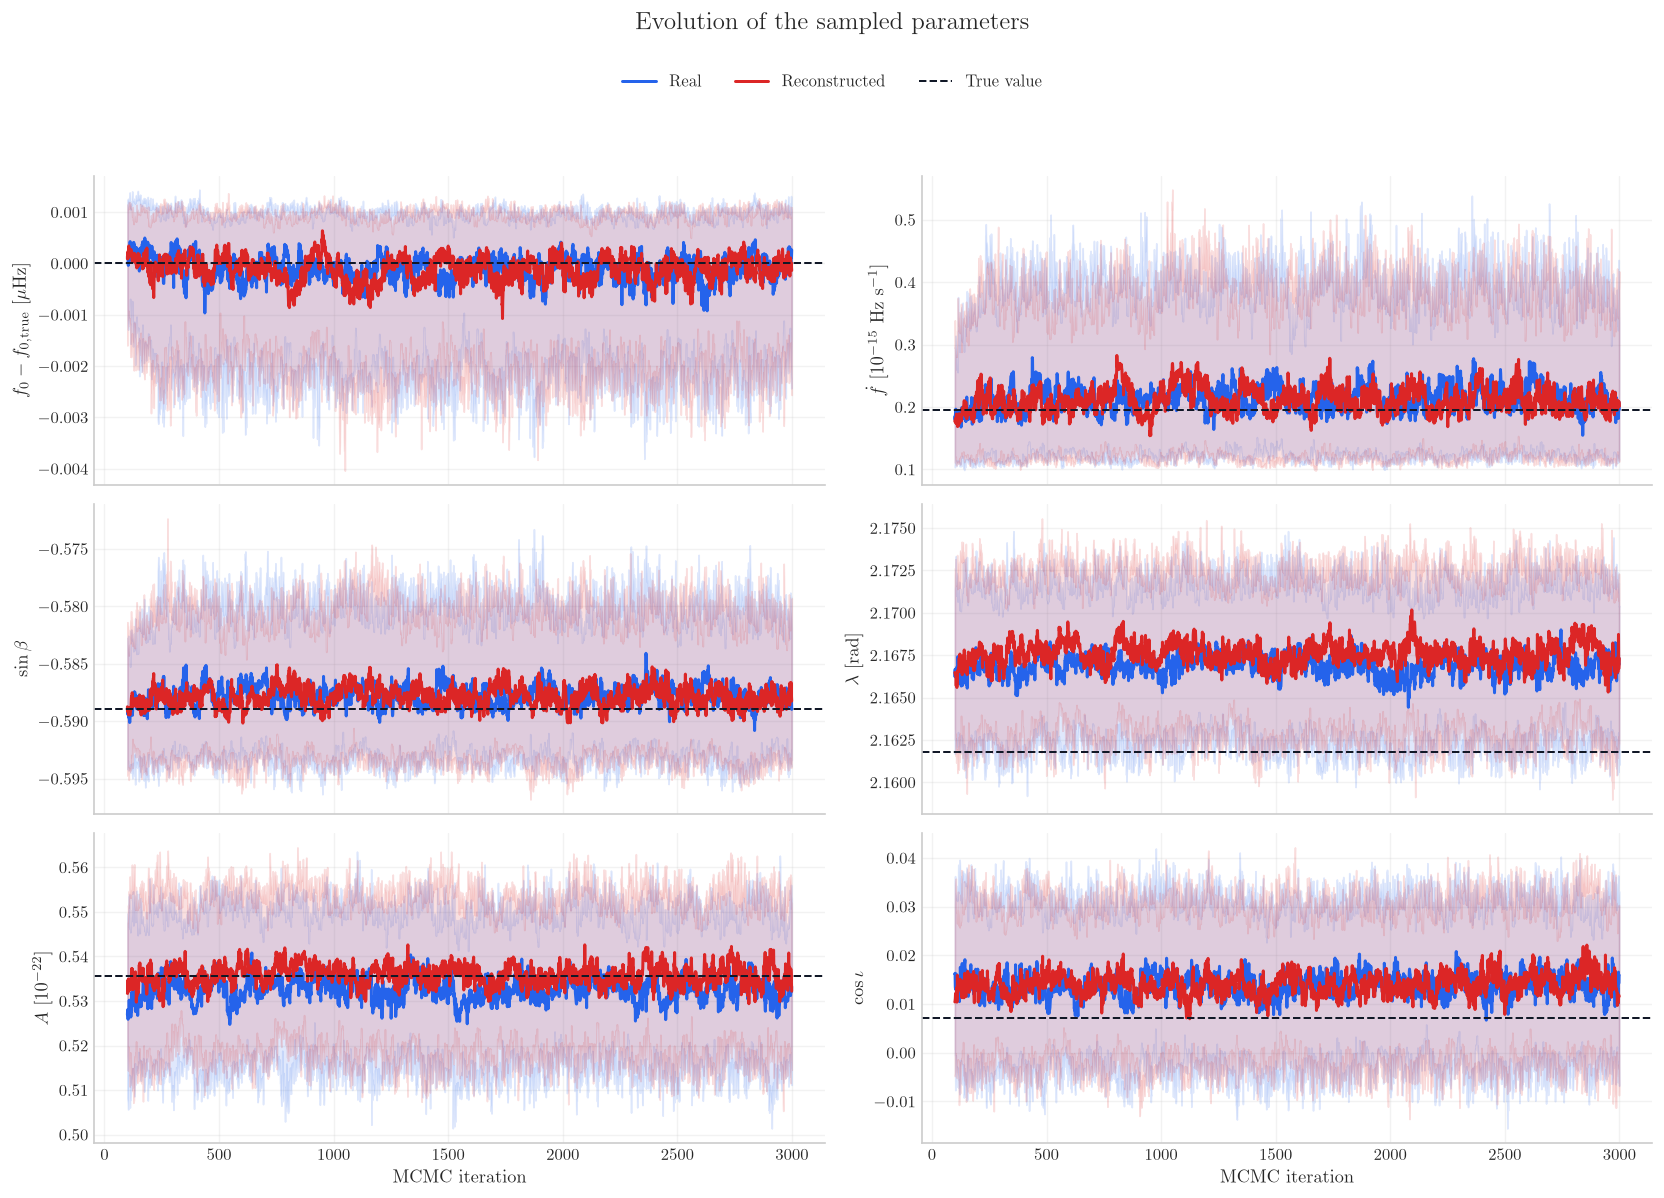

In [8]:
truth_for_plot = transform_parameters(truth, truth[0])
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for parameter_index, ax in enumerate(axes):
    for kind, label in (("real", "Real"), ("reconstructed", "Reconstructed")):
        chain = transform_parameters(posteriors[kind]["chain"], truth[0])
        values = chain[BURN_IN:, :, parameter_index]
        median, low, high = median_band(values)
        ax.plot(steps, median, color=COLORS[kind], lw=1.8, label=label)
        ax.fill_between(steps, low, high, color=COLORS[kind], alpha=0.14)
    ax.axhline(
        truth_for_plot[parameter_index], color="#111827", ls="--", lw=1.2,
        label="True value"
    )
    ax.set_ylabel(LABELS[parameter_index])
    ax.grid(alpha=0.25)
for ax in axes[-2:]:
    ax.set_xlabel("MCMC iteration")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper center",
    bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
)
fig.suptitle("Evolution of the sampled parameters", y=0.995, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

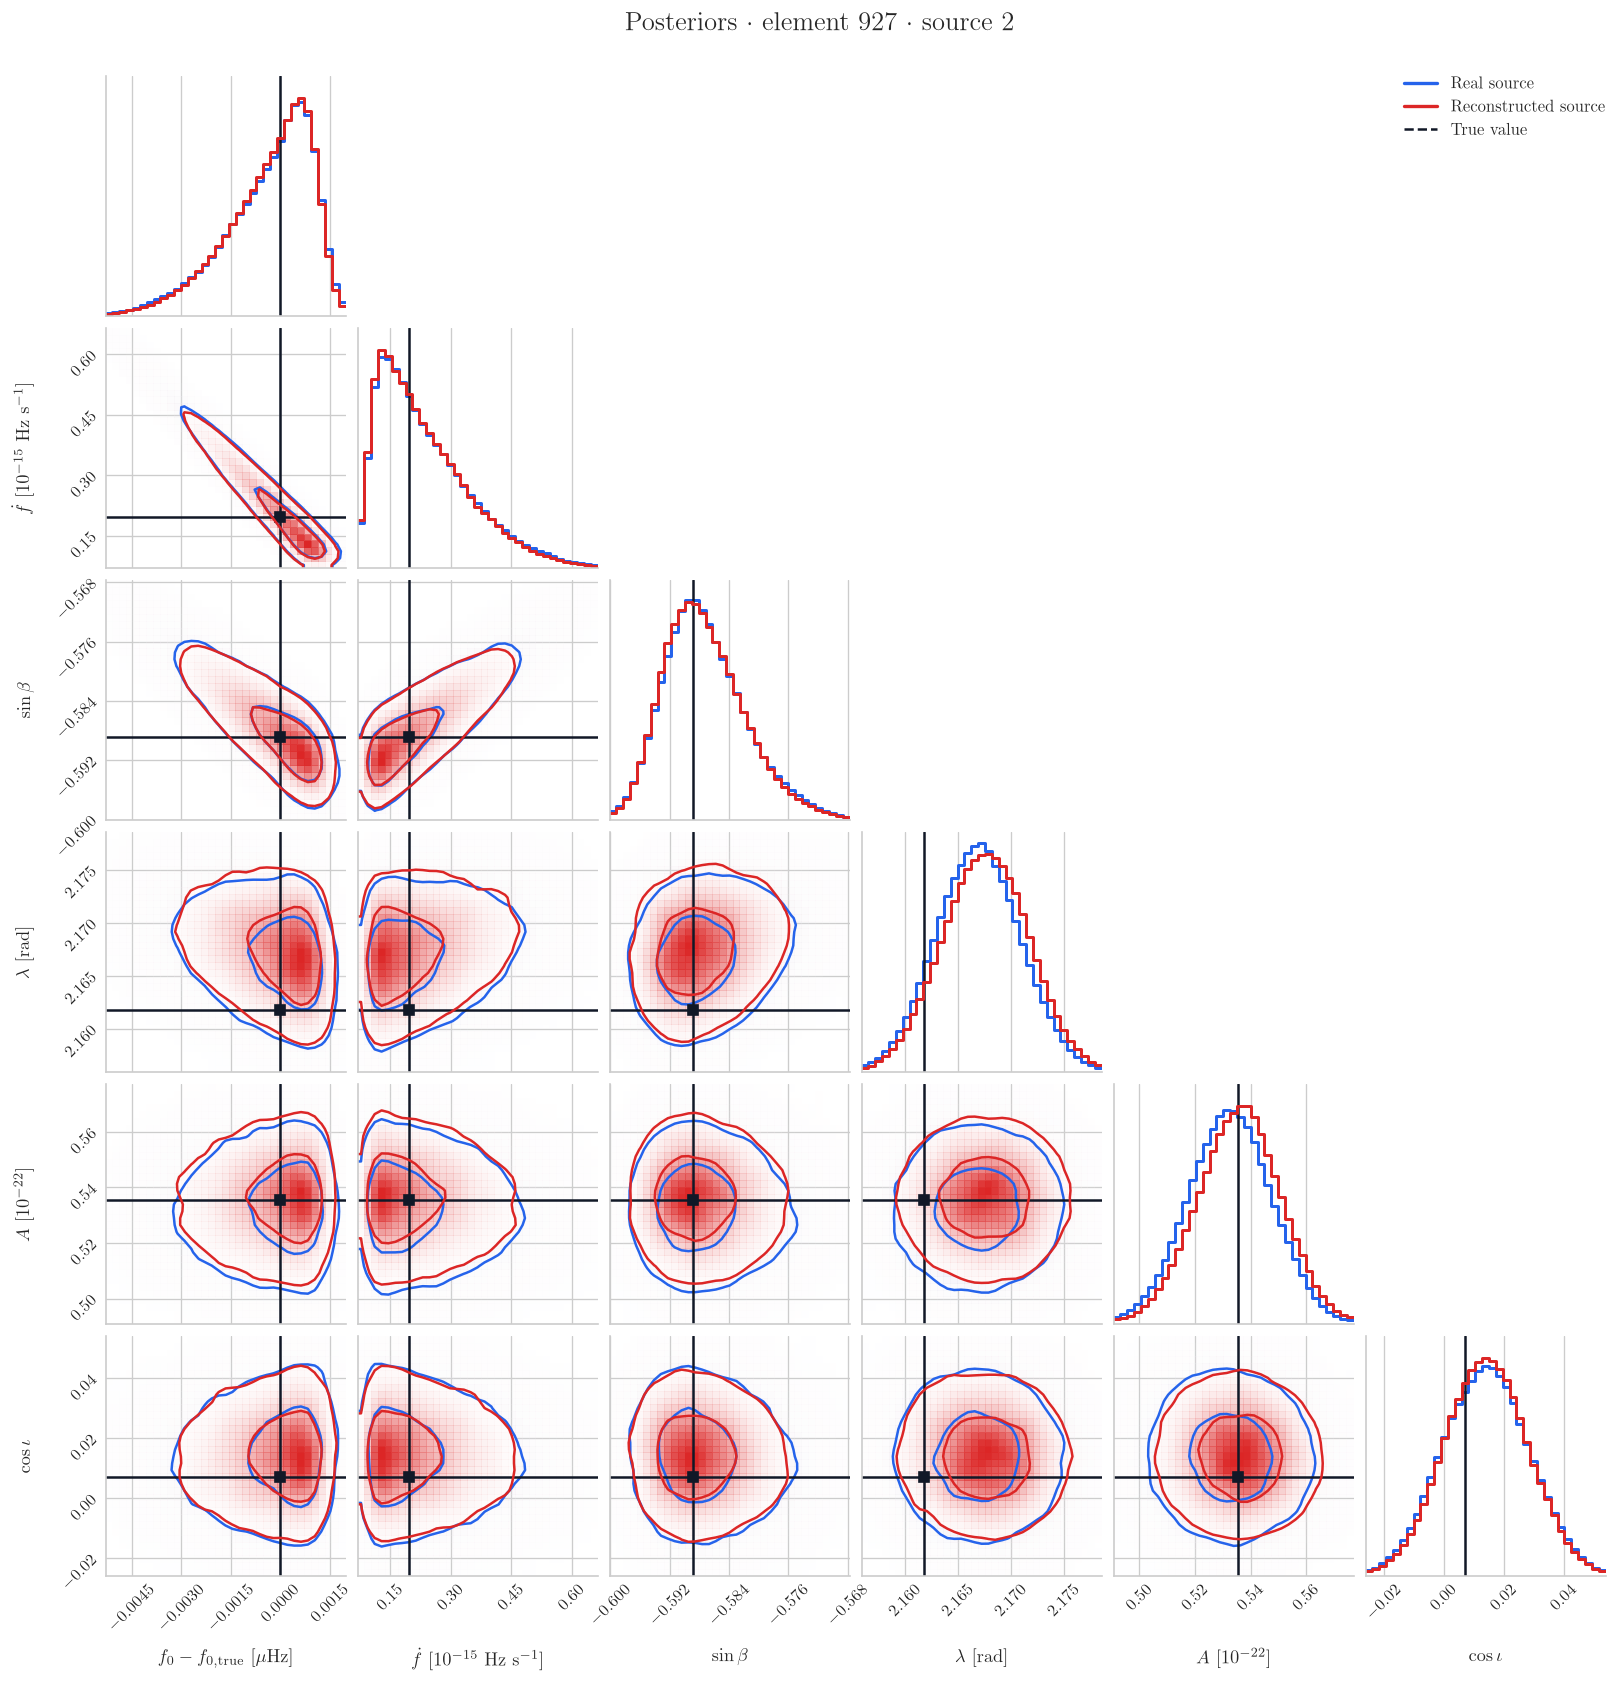

In [9]:
def samples_for_corner(kind):
    samples = posteriors[kind]["chain"][BURN_IN:].reshape(-1, len(LABELS))
    samples = transform_parameters(samples, truth[0])
    if len(samples) > MAX_CORNER_SAMPLES:
        indices = np.linspace(0, len(samples) - 1, MAX_CORNER_SAMPLES, dtype=int)
        samples = samples[indices]
    return samples


real_samples = samples_for_corner("real")
reconstructed_samples = samples_for_corner("reconstructed")
combined = np.vstack((real_samples, reconstructed_samples))
plot_ranges = []
for parameter_index in range(combined.shape[1]):
    low, high = np.quantile(combined[:, parameter_index], [0.005, 0.995])
    padding = 0.05 * (high - low) if high > low else 1.0
    plot_ranges.append((low - padding, high + padding))

figure = corner.corner(
    real_samples, labels=LABELS, truths=truth_for_plot, truth_color="#111827",
    color=BLUE, range=plot_ranges, bins=35, smooth=1.0, smooth1d=1.0,
    plot_datapoints=False, fill_contours=False, levels=(0.393, 0.865),
    hist_kwargs={"linewidth": 1.8},
    contour_kwargs={"linewidths": 1.5},
    label_kwargs={"fontsize": 11},
)
corner.corner(
    reconstructed_samples, fig=figure, color=RED, range=plot_ranges, bins=35,
    smooth=1.0, smooth1d=1.0, plot_datapoints=False, fill_contours=False,
    levels=(0.393, 0.865),
    hist_kwargs={"linewidth": 1.8},
    contour_kwargs={"linewidths": 1.5},
)
figure.legend(
    handles=[
        Line2D([0], [0], color=BLUE, lw=2, label="Real source"),
        Line2D([0], [0], color=RED, lw=2, label="Reconstructed source"),
        Line2D([0], [0], color="#111827", ls="--", lw=1.5, label="True value"),
    ],
    loc="upper right", bbox_to_anchor=(0.98, 0.98), frameon=False,
)
figure.suptitle(
    f"Posteriors · element {element_index} · source {source_number}",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.show()

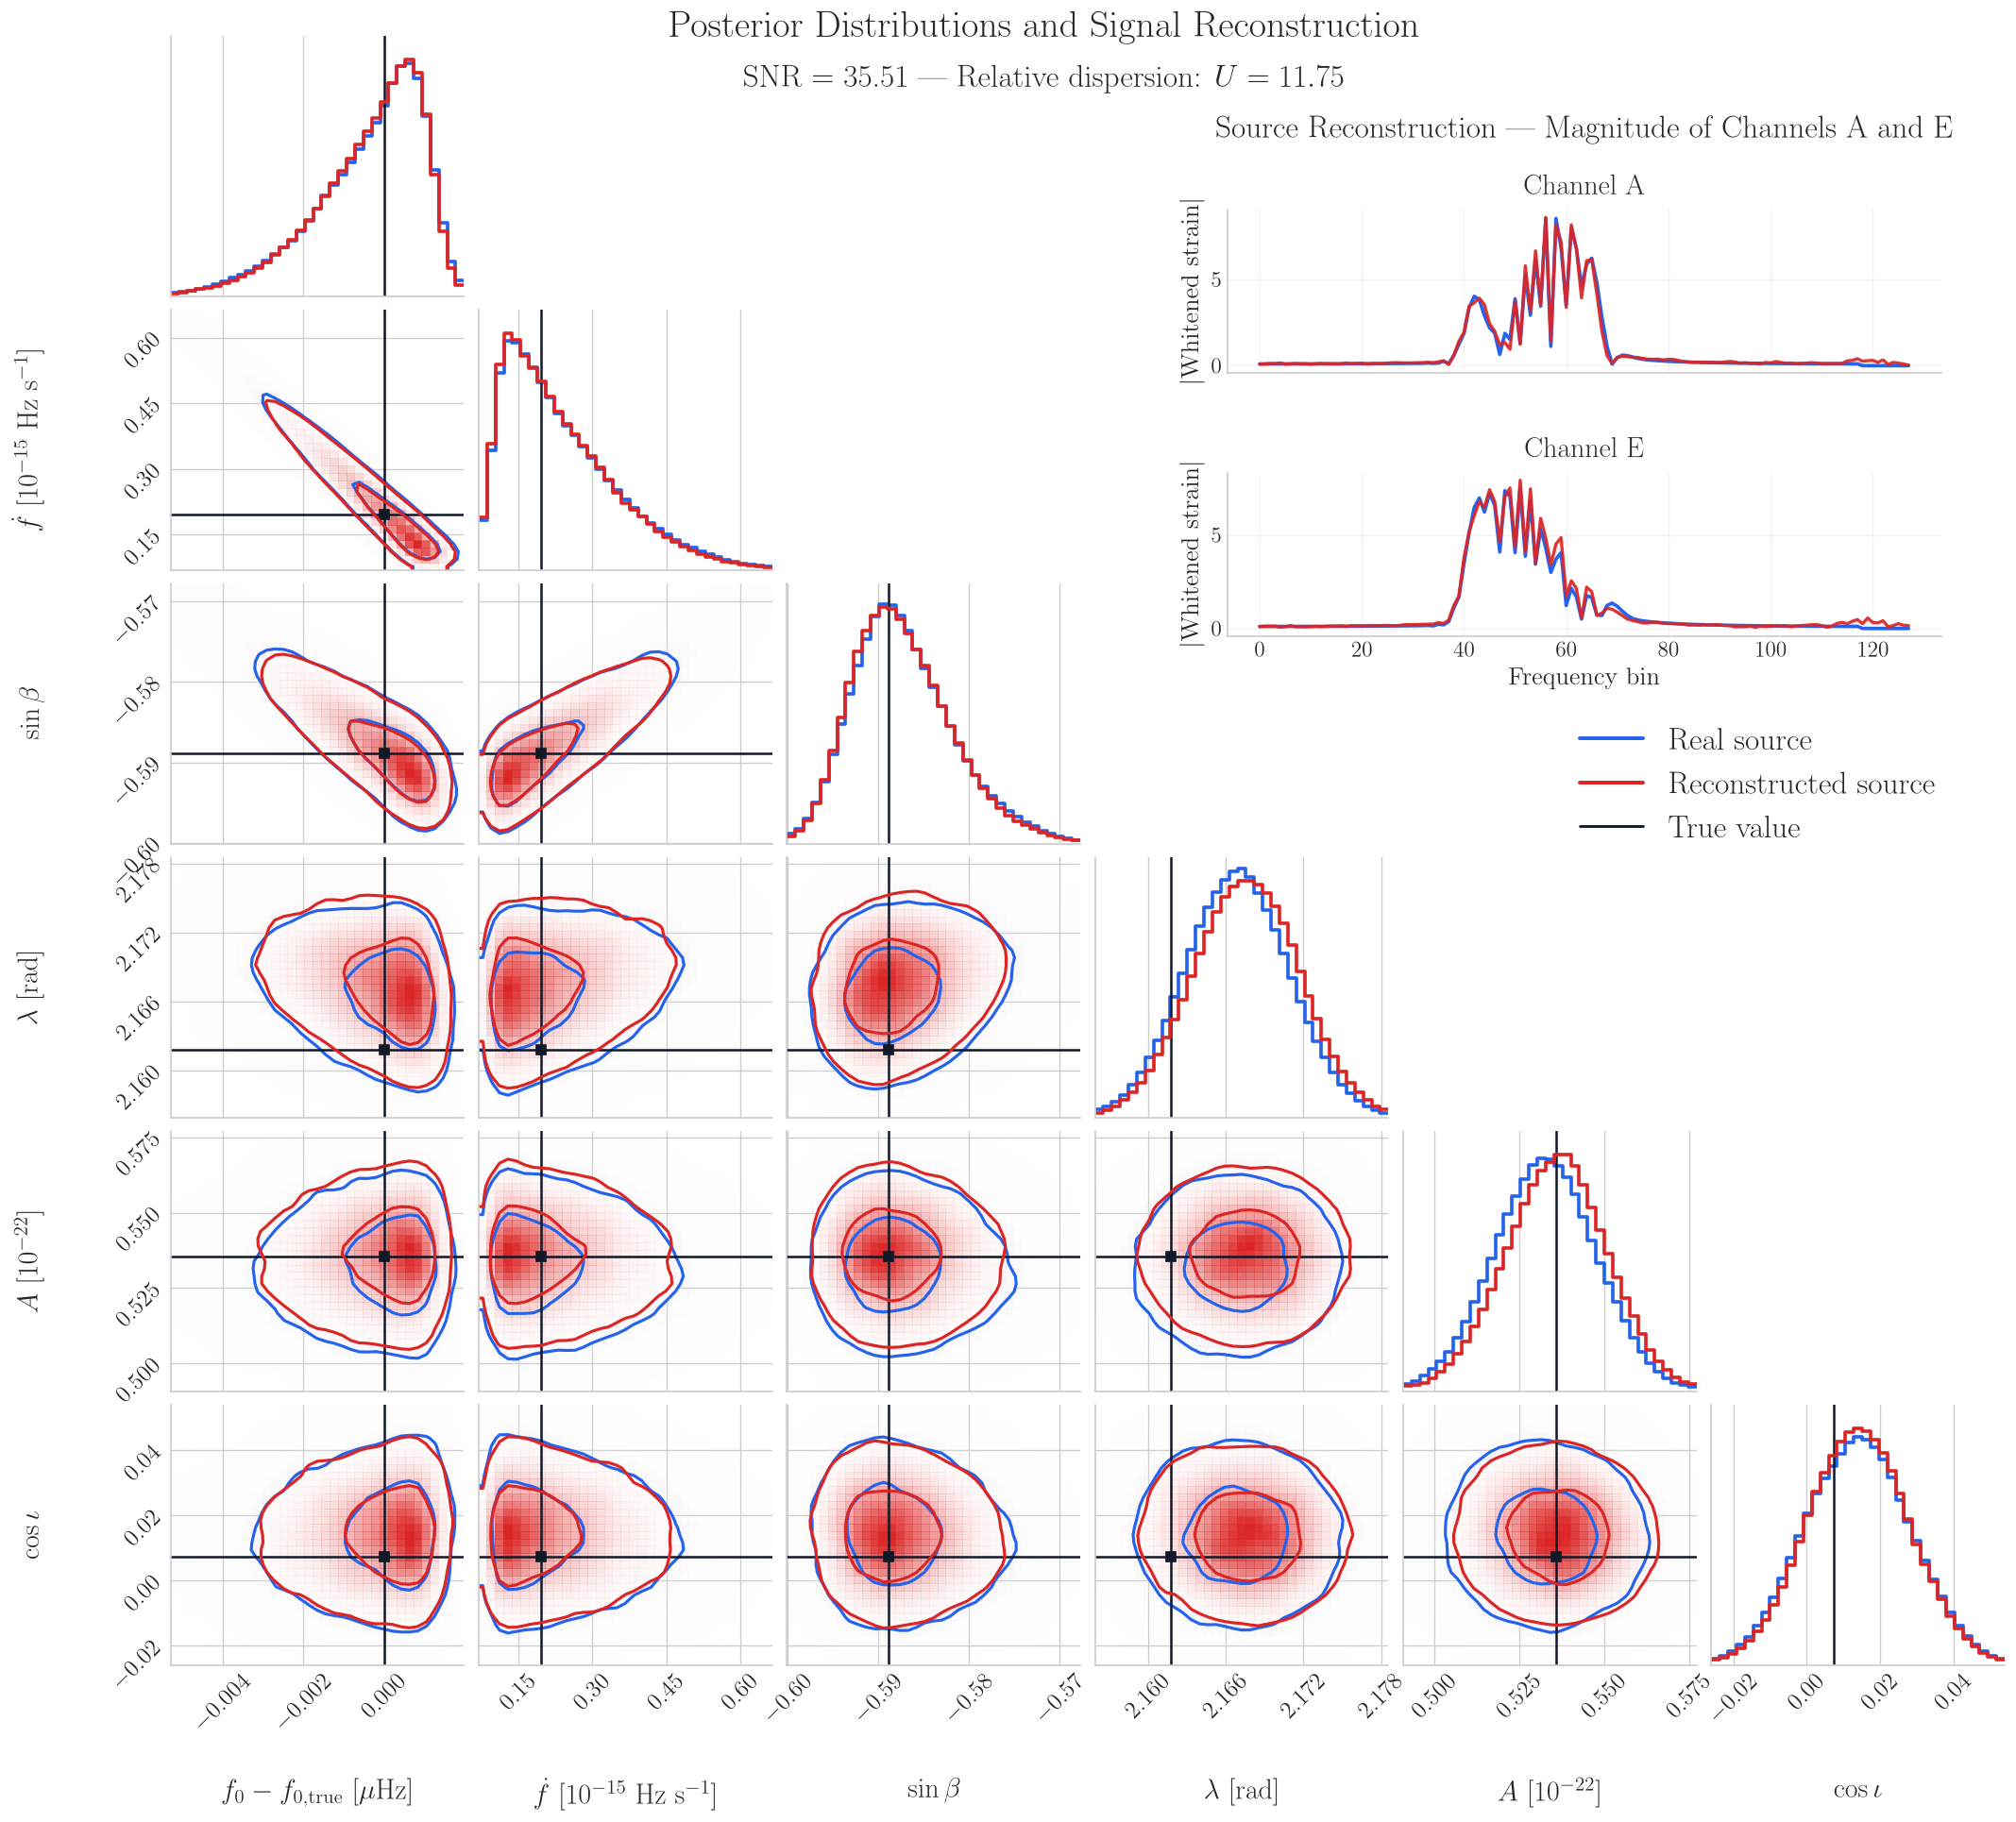

In [10]:
REPORT_LABELS = [
    r"$f_0-f_{0,\mathrm{true}}$ [$\mu$Hz]",
    r"$\dot f$ [$10^{-15}$ Hz s$^{-1}$]",
    r"$\sin\beta$",
    r"$\lambda$ [rad]",
    r"$A$ [$10^{-22}$]",
    r"$\cos\iota$",
]
REPORT_FONT = {
    "label": 18, "tick": 15, "legend": 20, "title": 24,
    "section": 20, "panel_title": 18, "panel_label": 16,
    "panel_tick": 14,
}

report_figure = plt.figure(figsize=(18, 16))
corner.corner(
    real_samples, fig=report_figure, labels=REPORT_LABELS,
    truths=truth_for_plot, truth_color="#111827", color=BLUE,
    range=plot_ranges, bins=35, smooth=1.0, smooth1d=1.0,
    plot_datapoints=False, fill_contours=False, levels=(0.393, 0.865),
    max_n_ticks=4, labelpad=0.13,
    hist_kwargs={"linewidth": 2.2},
    contour_kwargs={"linewidths": 1.9},
    label_kwargs={"fontsize": REPORT_FONT["label"]},
)
corner.corner(
    reconstructed_samples, fig=report_figure, color=RED,
    range=plot_ranges, bins=35, smooth=1.0, smooth1d=1.0,
    plot_datapoints=False, fill_contours=False, levels=(0.393, 0.865),
    max_n_ticks=4,
    hist_kwargs={"linewidth": 2.2},
    contour_kwargs={"linewidths": 1.9},
)

n_parameters = len(REPORT_LABELS)
corner_axes = np.asarray(report_figure.axes[: n_parameters**2]).reshape(
    n_parameters, n_parameters
)
for axis in corner_axes.ravel():
    axis.tick_params(axis="both", labelsize=REPORT_FONT["tick"])
    axis.xaxis.label.set_size(REPORT_FONT["label"])
    axis.yaxis.label.set_size(REPORT_FONT["label"])
corner_axes[-1, 0].set_xlabel(REPORT_LABELS[0], fontsize=REPORT_FONT["label"])

reconstruction_axes = [
    report_figure.add_axes([0.59, 0.785, 0.35, 0.09]),
    report_figure.add_axes([0.59, 0.64, 0.35, 0.09]),
]
for axis, channel, real_wave, reconstructed_wave in zip(
    reconstruction_axes,
    ("A", "E"),
    (real_a, real_e),
    (reconstructed_a, reconstructed_e),
):
    frequency_bins = np.arange(len(real_wave))
    axis.plot(frequency_bins, np.abs(real_wave), color=BLUE, lw=2.2)
    axis.plot(
        frequency_bins, np.abs(reconstructed_wave), color=RED, lw=2.0,
        alpha=0.92,
    )
    axis.fill_between(
        frequency_bins, np.abs(real_wave), np.abs(reconstructed_wave),
        color="#94A3B8", alpha=0.15,
    )
    axis.set_title(
        f"Channel {channel}", fontsize=REPORT_FONT["panel_title"], pad=10,
    )
    axis.set_ylabel(
        r"$|\mathrm{Whitened\ strain}|$",
        fontsize=REPORT_FONT["panel_label"],
    )
    axis.tick_params(axis="both", labelsize=REPORT_FONT["panel_tick"])
    axis.grid(alpha=0.25)
reconstruction_axes[-1].set_xlabel(
    "Frequency bin", fontsize=REPORT_FONT["panel_label"],
)
reconstruction_axes[0].tick_params(labelbottom=False)

report_figure.text(
    0.765, 0.915, "Source Reconstruction — Magnitude of Channels A and E",
    ha="center",
    fontsize=REPORT_FONT["section"], fontweight="bold",
)
legend_handles = [
    Line2D([0], [0], color=BLUE, lw=2.4, label="Real source"),
    Line2D([0], [0], color=RED, lw=2.4, label="Reconstructed source"),
    Line2D([0], [0], color="#111827", lw=1.7, label="True value"),
]

report_figure.legend(
    handles=legend_handles, loc="upper center",
    bbox_to_anchor=(0.85, 0.605), fontsize=REPORT_FONT["legend"],
    frameon=False, ncol=1,
)
report_figure.suptitle(
    "Posterior Distributions and Signal Reconstruction",
    fontsize=REPORT_FONT["title"], fontweight="bold", y=0.985,
)
report_figure.text(
    0.5, 0.955,
    f"SNR = {source_info['snr']:.2f}  —  "
    rf"Relative dispersion: $U = {relative_dispersion_u:.2f}$",
    ha="center", va="top", fontsize=REPORT_FONT["section"],
)

output_name = f"posterior_{"high" if source_info['snr'] > 50 else "medium" if source_info['snr'] > 30 else "low"}_snr_reconstruction_{source_info['reconstruction_quality']}"
plt.savefig(
    f"{output_name}.png", dpi=600, bbox_inches="tight",
    pad_inches=0.08, facecolor="white",
)

plt.show()